In [4]:
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
import numpy as np
import pandas as pd
from fredapi import Fred
import yfinance as yf

In [5]:
FIRST_DATE = "1954-01-03"
FINAL_DATE = "2024-12-31"
BITCOIN_D0 = "2017-09-07"  # according to Kasper's paper
AUTO_ADJUST = True
fred_api_key = "98af04c2eaf13d24aea2856385e845cc"

In [6]:
# "IS3S.DE"

universe = [
    "SPY", "QQQ", "IWM", # market
    "AGG", "TLT", "LQD", "TIP",  # bonds
    "XLK", "XLV", "XLF", "XLY", "XLI", "XLP", "XLE", "XLU", "XLB", "IBB", "IYR",  # sectors
    "GLD", "SLV", "PPLT", "CPER", "DBB",  # precious metals
    "DBC", "DBA", "CORN", "SOYB", "WOOD", "UNG", "USO", "WEAT", "CANE",  # commodities COTN.L
    "BTC-USD",  # crypto
    "EEM", "EWJ", "EWG", "EWU", "EWA", "EWH", "EWS", "EWZ", "EWT", "EWY", "EWP", "EWW", "EWD", "EWL", "EWC",  # international
]

etf_data: pd.DataFrame = yf.download(universe, start=FIRST_DATE, auto_adjust=AUTO_ADJUST)
closes: pd.DataFrame = etf_data["Close"]
trading_days = closes["SPY"].dropna().index
closes = closes.reindex(trading_days)
closes.loc[:BITCOIN_D0, "BTC-USD"] = np.nan
ret_d = closes.pct_change().dropna(how="all")

fred = Fred(api_key=fred_api_key)
ffr: pd.Series = fred.get_series("DFF")
ffr_y = ffr / 100
ffr_d = (ffr_y + 1.0) ** (1/252) - 1.0
ffr_y.shape, ffr_d.shape

def sharpe_geom(rd: pd.DataFrame, rf: pd.Series):
    assert rd.shape[0] == rf.shape[0]
    num_days = rd.notna().sum(axis=0)
    ret_ann = ((rd+1.0).prod() / (rf+1.0).prod()) ** (252 / num_days) - 1.0
    vol_ann = rd.std() * np.sqrt(252)
    return ret_ann / vol_ann

D0 = "2005-01-03"
D1 = "2024-12-31"
rd = ret_d.loc[D0:D1]
rf = ffr_d.reindex(rd.index)
rx = rd.sub(rf.values, axis=0)
rf_ann = (1.0+rf).prod() ** (252 / rf.shape[0]) - 1.0
na_count = rd.notna().sum(axis=0)

sharpe = sharpe_geom(rd, rf)
ret_ann = (1.0+rd).prod() ** (252 / na_count)-1.0
vol_ann = rd.std() * np.sqrt(252)
ret_tot = (1.0+rd).prod()-1.0

stats = pd.DataFrame({
    "sharpe": sharpe,
    "ret ann": ret_ann,
    "vol ann": vol_ann,
    "ret tot": ret_tot,
}, index=rd.columns)

stats.sort_values(by="sharpe", ascending=False)

[*********************100%***********************]  48 of 48 completed


,sharpe,ret ann,vol ann,ret tot
Ticker,,,,
BTC-USD,0.657239,0.528293,0.700947,21.093811
QQQ,0.585891,0.144971,0.215396,13.936735
XLK,0.559025,0.142343,0.221124,13.266689
XLP,0.520728,0.091304,0.140980,4.726170
XLV,0.476867,0.097317,0.166348,5.390297
SPY,0.445346,0.102845,0.190333,6.064994
XLY,0.424206,0.110948,0.218605,7.177202
GLD,0.407579,0.089382,0.175479,4.528082
XLU,0.376563,0.088618,0.187937,4.451166


Ticker,SPY,XLK,XLV,XLF,XLY,XLI,XLP,XLE,XLU,XLB,IBB,IYR
Ticker,,,,,,,,,,,,
SPY,1.000000,0.869794,0.779706,0.827292,0.859126,0.882624,0.675569,0.656072,0.607629,0.783204,0.698545,0.705749
XLK,0.869794,1.000000,0.648130,0.626353,0.735860,0.727747,0.462772,0.450041,0.437135,0.600335,0.649879,0.527182
XLV,0.779706,0.648130,1.000000,0.623051,0.665025,0.707049,0.612564,0.473541,0.528255,0.620098,0.751854,0.535877
XLF,0.827292,0.626353,0.623051,1.000000,0.737873,0.782282,0.573381,0.575476,0.493138,0.692075,0.539942,0.757826
XLY,0.859126,0.735860,0.665025,0.737873,1.000000,0.799373,0.592590,0.512304,0.476025,0.708594,0.625731,0.662294
XLI,0.882624,0.727747,0.707049,0.782282,0.799373,1.000000,0.621146,0.645795,0.550695,0.818586,0.621978,0.670191
XLP,0.675569,0.462772,0.612564,0.573381,0.592590,0.621146,1.000000,0.441133,0.594227,0.567517,0.513232,0.564281
XLE,0.656072,0.450041,0.473541,0.575476,0.512304,0.645795,0.441133,1.000000,0.474990,0.677591,0.436707,0.509451
XLU,0.607629,0.437135,0.528255,0.493138,0.476025,0.550695,0.594227,0.474990,1.000000,0.515317,0.410608,0.564331


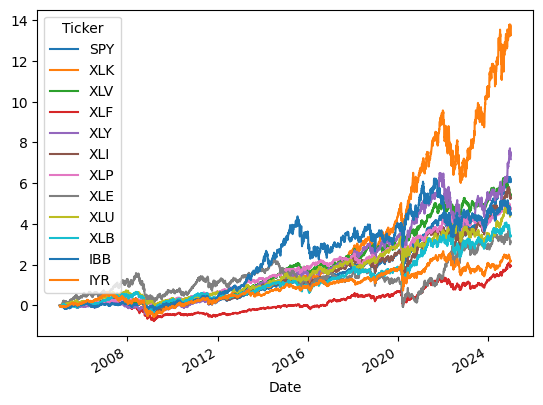

In [9]:
((ret_d[["SPY", "XLK", "XLV", "XLF", "XLY", "XLI", "XLP", "XLE", "XLU", "XLB", "IBB", "IYR",]].loc[D0:D1]+1.0).cumprod()-1.0).plot(legend=True)
ret_d[["SPY", "XLK", "XLV", "XLF", "XLY", "XLI", "XLP", "XLE", "XLU", "XLB", "IBB", "IYR",]].corr()

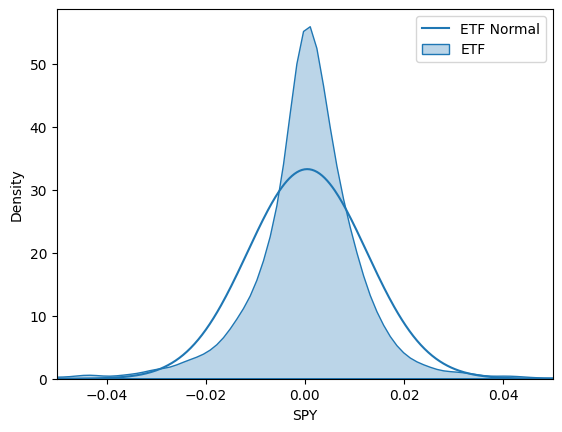

(np.float64(0.00046231960860153916), np.float64(0.01198871671515105))

In [10]:
D0 = "2005-01-03"
D1 = "2010-01-03"
D2 = "2015-01-03"
D3 = "2020-01-03"
D4 = "2025-01-03"

etf = ret_d["SPY"].loc[D0:D4]
mu = etf.mean()
sigma = etf.std()

norm_pdf = lambda x: 1/np.sqrt(2*np.pi*sigma**2) * np.exp(-0.5 * (x - mu)**2 / sigma**2)
x = np.linspace(etf.min(), etf.max(), 1000)

plt.plot(x, norm_pdf(x), label="ETF Normal")
sns.kdeplot(etf, label="ETF", fill=True, alpha=0.3)
plt.xlim(-0.05, 0.05)
plt.legend()
plt.show()
mu, sigma

In [58]:
ret_d.to_parquet("./return/return_d.parquet")

# store risk free return (Fed Fund Rate - FFR)
pd.DataFrame(ffr_d, columns=["DFF"]).to_parquet("./return/ffr_d.parquet")
pd.DataFrame(ffr_y, columns=["DFF"]).to_parquet("./return/ffr_y.parquet")

In [ ]:
# NOTE Regress Sectors and International ETFs on market (potentially gold and bonds as well)
# Rank idiosyncratic returns to get assets that perform well orthogonally to the market
# Otherwise predictor may rank which ETF has biggest market component

# Ai = B * SPY + ei
# ei = Ai - B * SPY
spy = rd["SPY"]
Am  = rd.drop(columns="SPY")
Be = Am.mul(spy, axis=0).sum(axis=0) / (spy @ spy)
eps = Am.sub(Be.values[None, :] * spy.values[:, None])
Be.sort_values()

Ticker
TLT       -0.250879
TIP       -0.036011
AGG       -0.002474
WEAT       0.028987
GLD        0.053567
SOYB       0.076818
CORN       0.079064
LQD        0.085502
CANE       0.094286
UNG        0.222676
CPER       0.225270
DBA        0.242571
PPLT       0.263119
BTC-USD    0.356373
SLV        0.359491
DBC        0.399731
DBB        0.428582
XLP        0.570542
XLU        0.650593
USO        0.673890
XLV        0.716780
EWL        0.799793
EWJ        0.808476
IBB        0.883703
EWH        0.897500
EWS        0.920996
WOOD       0.929509
EWC        0.939361
EWT        0.952480
EWU        0.995384
XLI        0.996901
XLY        1.029899
QQQ        1.038804
XLB        1.058012
XLK        1.062233
EWW        1.079066
EWG        1.091074
EWP        1.092508
IWM        1.138148
IYR        1.138834
XLE        1.154056
EWA        1.172603
EWY        1.193762
EEM        1.212638
EWD        1.236201
XLF        1.309507
EWZ        1.355571
dtype: float64

In [ ]:
# timeline = pd.date_range(start=D0, end=D1)
# day_of_wk = np.cos(2*np.pi / 7 * timeline.day_of_week)
# day_of_mt = np.cos(2*np.pi / 31 * timeline.day)
# day_of_yr = np.cos(2*np.pi / 365 * timeline.day_of_year)